## Alzheimer Prediction Project

This project explores interpretable machine learning for Alzheimer's disease classification using a synthetic patient dataset. Logistic Regression, Random Forest, and XGBoost are compared for predictive performance, while SHAP is used to interpret Random Forest predictions, PCA is used to explore the overall patient data structure, and MAPIE conformal prediction is used to quantify prediction uncertainty.


## 1. Import Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap
from sklearn.decomposition import PCA
from mapie.classification import SplitConformalClassifier




In [71]:
df = pd.read_csv("alzheimers_disease_data.csv")
df.head()
df.isna().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

## 2. Data Description

In [72]:
df.shape
df.isna().sum()
df.info()
df.describe()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

np.int64(0)

### Interpretation

The dataset contains no missing values, indicating that no imputation is required before model training.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Diagnosis Distribution

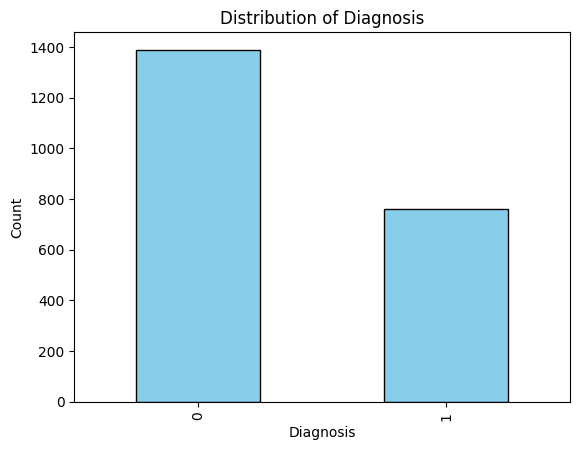

In [73]:
# Diagnosis Distribution
diagnosis_counts = df["Diagnosis"].value_counts().plot(kind='bar',color="skyblue", edgecolor="black")
plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


### 3.2 Age Distribution

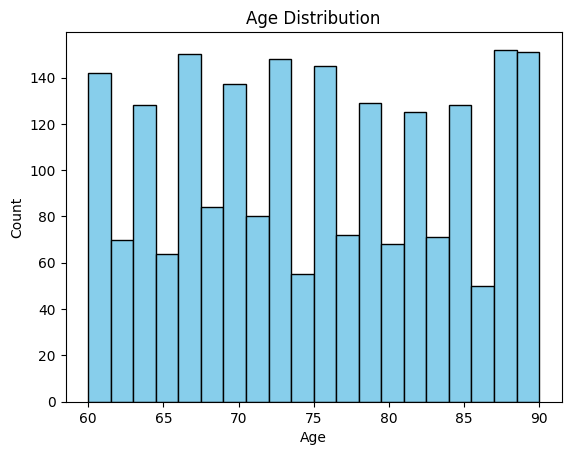

In [74]:
#Age Distribution
age_distribution = df["Age"].plot(kind='hist', bins=20, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### 3.3 Cognitive & Functional Measures

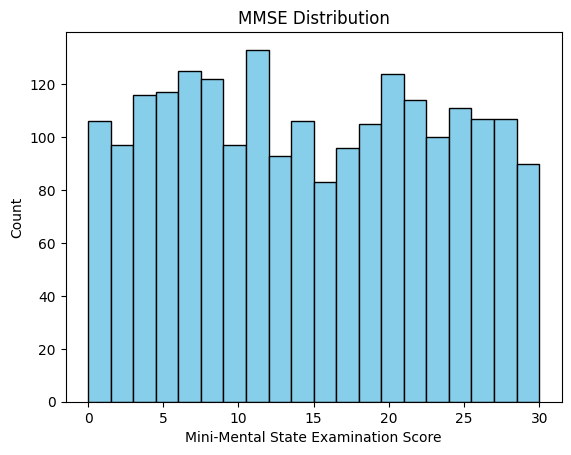

In [ ]:
# MMSE Distribution

MMSE_distribution = df["MMSE"].plot(kind='hist', bins=20, color="skyblue", edgecolor="black")
plt.title("MMSE Distribution")
plt.xlabel("Mini-Mental State Examination Score")
plt.ylabel("Frequency")
plt.show()


MMSE scores are approximately evenly distributed across the observed range, with no obvious concentration around a particular score.

In [2]:
plt.hist(df["ADL"], bins=20, edgecolor="black", color="skyblue")

plt.title("ADL Distribution")

plt.xlabel("ADL")

plt.ylabel("Frequency")

plt.show()

NameError: name 'plt' is not defined

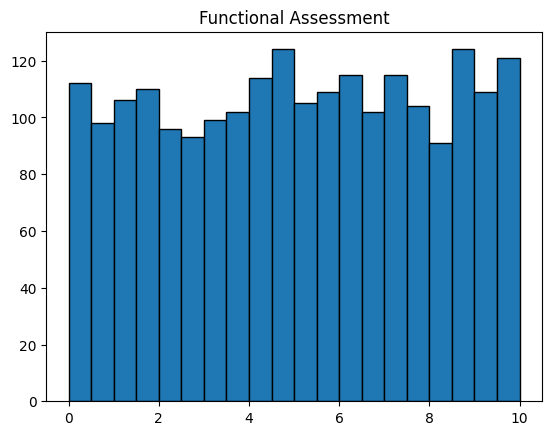

In [ ]:
plt.hist(df["FunctionalAssessment"], bins=20, edgecolor="black")

plt.title("Functional Assessment")
plt.xlabel("Functional Assessment")
plt.ylabel("Frequency")
plt.show()

### 3.4 Correlation Analysis

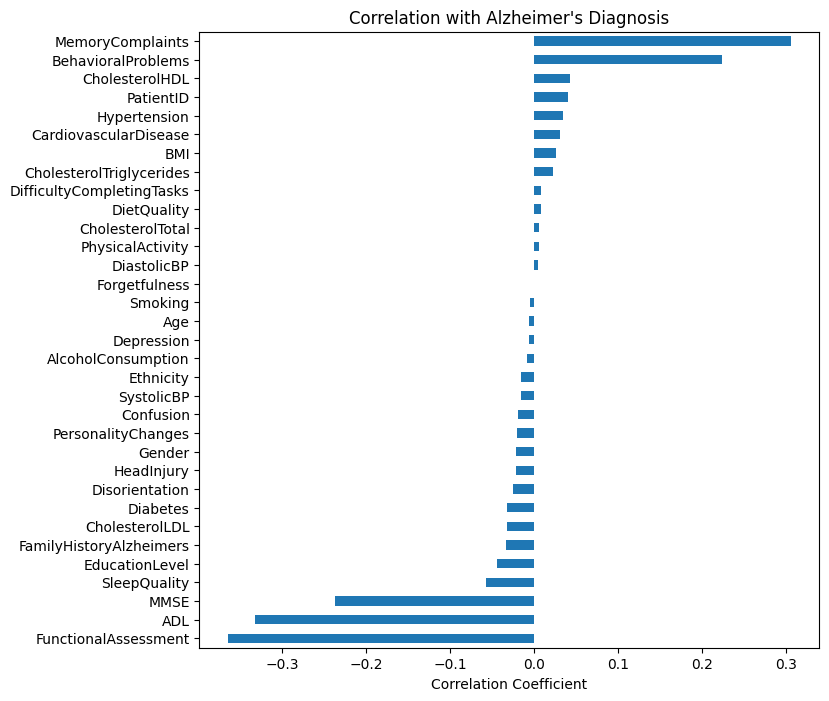

In [80]:
corr = df.corr(numeric_only=True)

corr["Diagnosis"].sort_values(ascending=False)

corr["Diagnosis"]\
    .drop("Diagnosis")\
    .sort_values()\
    .plot(kind="barh", figsize=(8,8))

plt.title("Correlation with Alzheimer's Diagnosis")
plt.xlabel("Correlation Coefficient")

plt.show()

In [81]:
cols = [
    "Diagnosis",
    "MMSE",
    "ADL",
    "FunctionalAssessment",
    "MemoryComplaints",
    "Forgetfulness"
]

small_corr = df[cols].corr()

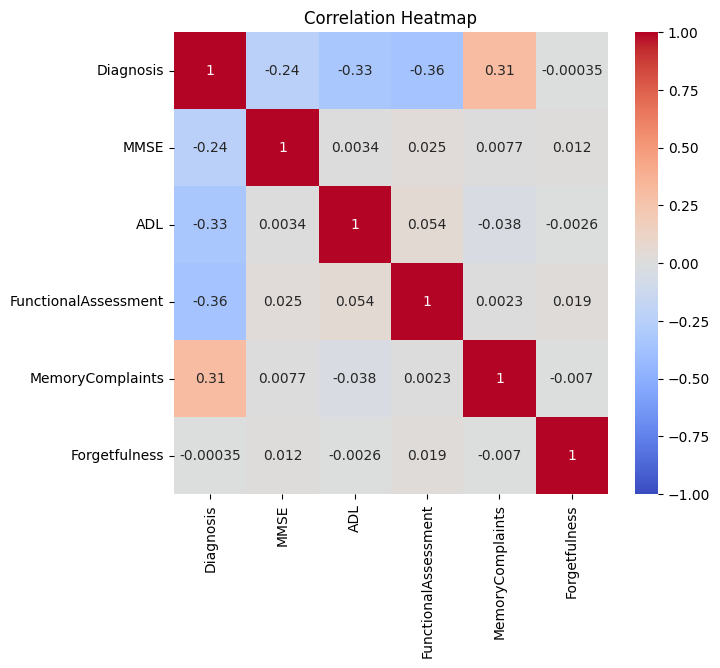

In [ ]:
plt.figure(figsize=(7,6))

sns.heatmap(
    small_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")
plt.show()


In [83]:
corr["Diagnosis"].abs().sort_values(ascending=False)

Diagnosis                    1.000000
FunctionalAssessment         0.364898
ADL                          0.332346
MemoryComplaints             0.306742
MMSE                         0.237126
BehavioralProblems           0.224350
SleepQuality                 0.056548
EducationLevel               0.043966
CholesterolHDL               0.042584
PatientID                    0.041019
Hypertension                 0.035080
FamilyHistoryAlzheimers      0.032900
CholesterolLDL               0.031976
Diabetes                     0.031508
CardiovascularDisease        0.031490
BMI                          0.026343
Disorientation               0.024648
CholesterolTriglycerides     0.022672
HeadInjury                   0.021411
Gender                       0.020975
PersonalityChanges           0.020627
Confusion                    0.019186
SystolicBP                   0.015615
Ethnicity                    0.014782
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
AlcoholConsu

## 4. Data Preprocessing
The dataset is prepared for model training by removing non-predictive columns, separating features from the target, and checking whether additional preprocessing is required.

In [84]:
df_model = df.copy()
# Dropping non-predictive columns
df_model = df_model.drop(columns=["PatientID", "DoctorInCharge"])

In [85]:
# Checking for categorical features
X = df_model.drop(columns=["Diagnosis"])
y = df_model["Diagnosis"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2149, 32)
y Shape: (2149,)


In [86]:
# Checking for categorical features, missing values, and duplicates
X.select_dtypes(include="object").columns
X.isna().sum().sum()
df_model.duplicated().sum()

np.int64(0)

In [87]:
y.value_counts()
y.value_counts(normalize=True)

Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64

## 5. Train-Test Split
The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [ ]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

# Checking the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

# Checking the distribution of the target variable in the original, training, and testing sets
print("Original")
print(y.value_counts(normalize=True))

print("\nTraining")
print(y_train.value_counts(normalize=True))

print("\nTesting")
print(y_test.value_counts(normalize=True))

Training set shape: (1719, 32) (1719,)
Testing set shape: (430, 32) (430,)
Original
Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64

Training
Diagnosis
0    0.646306
1    0.353694
Name: proportion, dtype: float64

Testing
Diagnosis
0    0.646512
1    0.353488
Name: proportion, dtype: float64


### Interpretation

The dataset was split into training (80%) and testing (20%) sets. Stratified sampling was applied to preserve the class distribution of Alzheimer's diagnoses in both subsets, ensuring a fair evaluation of model performance.

## Modeling Approach

Three classification models were evaluated for different purposes. Logistic Regression was used as a baseline model, Random Forest was used as the primary model for interpretability and uncertainty analysis, and XGBoost was used as a stronger tree-based benchmark. Model performance was evaluated using accuracy, precision, recal, and F1-score, with particular attention to Alzheimer's patients (Class 1). 

## 6. Logistic Regression

### 6.1 Model Prediction

In [ ]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [90]:
y_pred_logreg = logreg.predict(X_test_scaled)
print(y_pred_logreg[:10])

[1 0 1 0 1 0 1 0 1 1]


### 6.2 Model Evaluation

In [91]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))

print(classification_report(y_test, y_pred_logreg))

Accuracy: 0.8162790697674419
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       278
           1       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430



### Interpretation

The Logistic Regression model achieved an overall accuracy of **81.6%** on the test set. For Alzheimer's patients (Class 1), the model obtained a **precision of 0.74**, and a **recall of 0.74**, meaning that 74% of actual Alzheimer's patients were successfully identified. The F1-score of **0.74** demonstrates a moderate balance between precision and recall. Overall, the model showed reasonable predictive performance but had limitations in accurately identifying Alzheimer's patients.

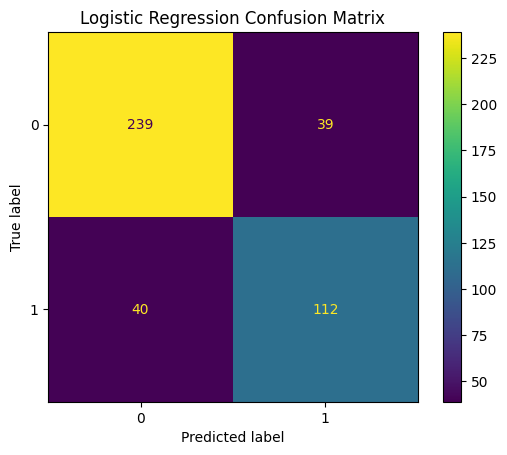

In [ ]:
cm = confusion_matrix(y_test, y_pred_logreg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix shows that the Logistic Regression model correctly classified 239 healthy individuals and 112 patients with Alzheimer's disease. 39 healthy individuals were incorrectly classified as having Alzheimer's (false positives), while 40 Alzheimer's patients were incorrectly classified as healthy (false negatives). In a clinical setting, false negatives are particularly important because missed diagnoses may delay treatment and intervention. 

## 7. Random Forest - Primary Model

In [ ]:
# Initializing the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 7.1 Model Prediction
The trained Random Forest model is used to predict Alzheimer's diagnoses for the unseen test dataset.

In [94]:
y_pred = rf.predict(X_test)
print("Predictions:", y_pred[:10])

Predictions: [1 0 1 0 1 0 1 0 0 1]


### 7.2 Model Evaluation


In [ ]:
# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9372


In [ ]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430



### Interpretation

The Random Forest model achieved an overall accuracy of **93.7%** on the test set. For Alzheimer's patients (Class 1), the model obtained a **precision of 0.94**, indicating that most predicted Alzheimer's cases were correct, and a **recall of 0.88**, meaning that 88% of actual Alzheimer's patients were successfully identified. The F1-score of **0.91** demonstrates a good balance between precision and recall. Overall, the model shows strong predictive performance compared to the Logistic Regression model, although reducing false negatives would further improve its usefulness in clinical settings. 

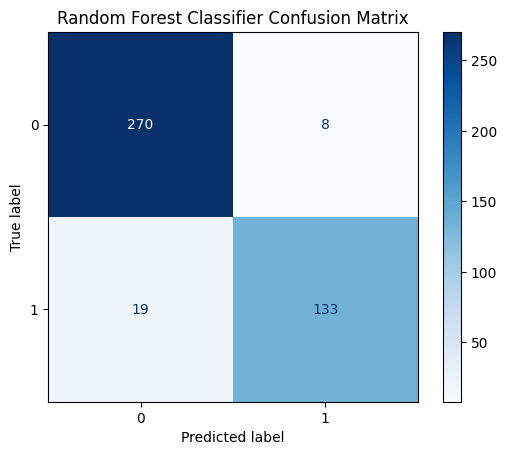

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    rf, 
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Classifier Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix shows that the Random Forest model correctly classified 270 healthy individuals and 133 patients with Alzheimer's disease. Eight healthy individuals were incorrectly classified as having Alzheimer's (false positives), while 19 Alzheimer's patients were incorrectly classified as healthy (false negatives). In a clinical setting, false negatives are particularly important because missed diagnoses may delay treatment and intervention. 

## 8. XGBoost

### 8.1 Model Training

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### 8.2 Model Evaluation

In [99]:
y_pred_xgb = xgb.predict(X_test)
print(y_pred_xgb[:10])

[1 0 1 1 1 0 1 0 0 1]


In [100]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)

print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9488372093023256
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.94      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



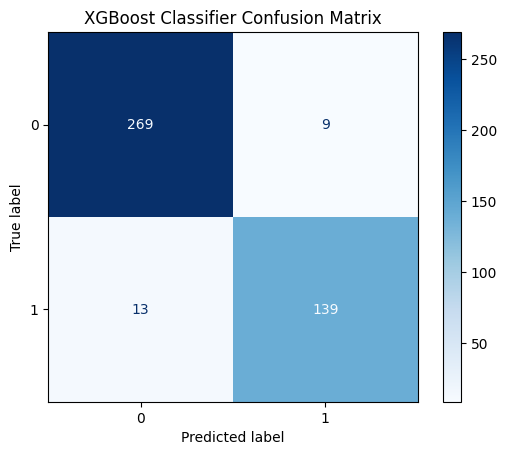

In [101]:
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
    cmap="Blues"    
)

plt.title("XGBoost Classifier Confusion Matrix")
plt.show()


### Interpretation

Although XGBoost achieved slightly higher predictive performance than Random Forest, Random Forest was selected as the primary model because it provided strong predictive performance while maintaining a relatively simple tree-based structure suitable for model interpretation. This choice is particularly relevant in healthcare, where understanding the factors contributing to model predictions is important.

## 9. Model Comparison

In [ ]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_logreg), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_xgb)],
    "Precision(Class 1)": [classification_report(y_test, y_pred_logreg, output_dict=True)['1']['precision'], 
                           classification_report(y_test, y_pred, output_dict=True)['1']['precision'], 
                           classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision']],
    "Recall(Class 1)": [classification_report(y_test, y_pred_logreg, output_dict=True)['1']['recall'], 
                        classification_report(y_test, y_pred, output_dict=True)['1']['recall'], 
                        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall']],
    "F1-Score(Class 1)": [classification_report(y_test, y_pred_logreg, output_dict=True)['1']['f1-score'], 
                          classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'], 
                          classification_report(y_test, y_pred_xgb, output_dict=True)['1']['f1-score']]
})

model_results

,Model,Accuracy,Precision(Class 1),Recall(Class 1),F1-Score(Class 1)
0,Logistic Regression,0.816279,0.741722,0.736842,0.739274
1,Random Forest,0.937209,0.943262,0.875000,0.907850
2,XGBoost,0.948837,0.939189,0.914474,0.926667


### Interpretation

Among the three models, XGBoost achieved the highest predictive performance, with an accuracy of 94.9% and an F1-score of 0.93 for Alzheimer's patients. Random Forest performed comparably, achieving an accuracy of 93.7% and an F1-score of 0.91, while Logistic Regression showed lower performance with an accuracy of 81.6%.

Although XGBoost achieved slightly higher predictive performance, Random Forest was retained as the primary model for further interpretation and uncertainty analysis. It provided strong predictive performance while allowing its predictions to be further examined using SHAP and conformal prediction with MAPIE. This balance between predictive performance, interpretability, and uncertainty analysis is particularly relevant in a healthcare modeling context.

## 10. Feature Importance

Feature importance measures how much each predictor contributes to the Random Forest model. Features with higher importance have a greater influence on the model's predictions. 

In [102]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)  

feature_importance.head(10)

,Feature,Importance
23,FunctionalAssessment,0.179463
26,ADL,0.167452
22,MMSE,0.116973
24,MemoryComplaints,0.084173
25,BehavioralProblems,0.045570
7,PhysicalActivity,0.031212
8,DietQuality,0.030738
20,CholesterolHDL,0.030027
9,SleepQuality,0.029586
4,BMI,0.029194


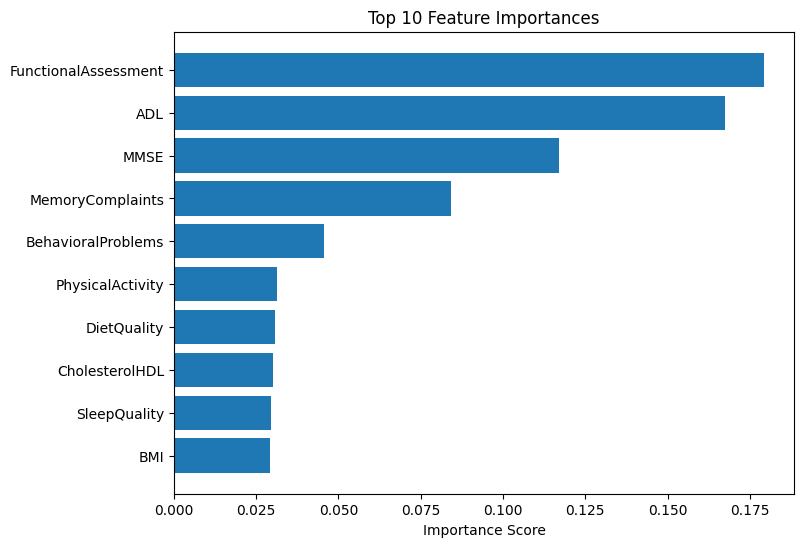

In [103]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")

plt.show()



### Interpretation

FunctionalAssessment and ADL were the most important features, followed by MMSE, MemoryComplaints, and BehavioralProblems. These results suggest that functional and cognitive measures played a major role in the Random Forest predictions.

Feature importance does not show the direction of each feature's effect, so SHAP analysis is used next for further interpretation.

## 11. SHAP 

SHAP explains how each feature contributes to the model's prediction. 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


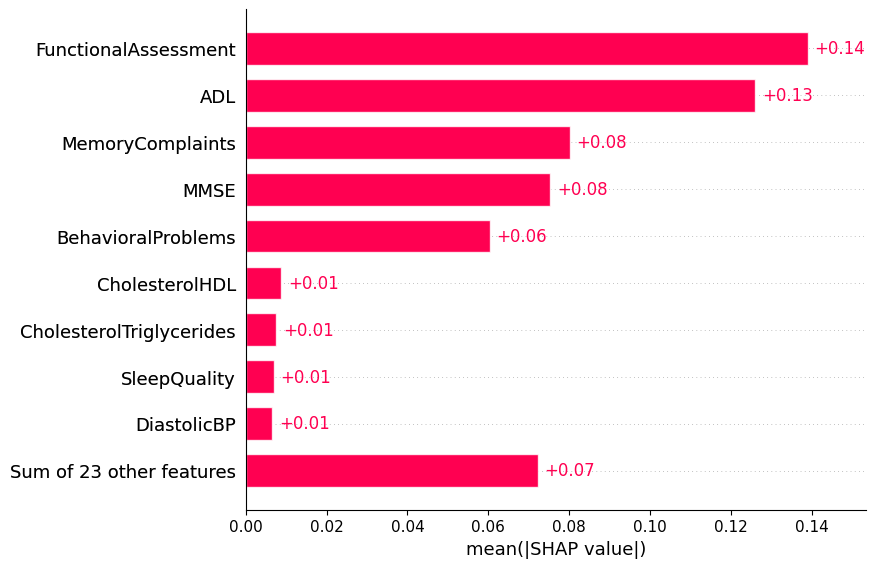

In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

# Select class 1: Alzheimer's disease
shap_values_alz = shap_values[:, :, 1]

# Bar Plot for SHAP values
shap.plots.bar(shap_values_alz)

### Interpretation

The SHAP bar plot summarizes the average magnitude of each feature's contribution to the model's predictions. FunctionalAssessment, ADL, MMSE, and MemoryComplaints have the largest mean absolute SHAP values, indicating that these features have the greatest overall influence on the model's predictions.

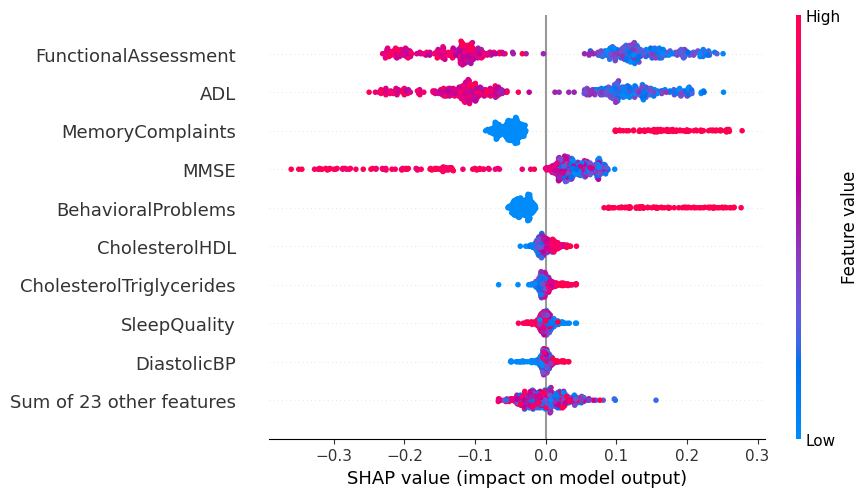

In [105]:

# Beeswarm Plot for SHAP values
shap.plots.beeswarm(shap_values_alz)

### Interpretation
The SHAP beeswarm plot shows the Functional Assessment, ADL, Memory Complaints, MMSE, Behavioral Problems are the most influential feature in the model's prediction. Lower Functional Assessment, ADL, and MMSE values generally contributes to positive SHAP values, pushing predictions toward Alzheimer's disease. Similarly, the presence of Memory Complaints(Memory Complaints = 1) and Behavioral Problems (Behavioral Problems = 1) tend to push prediction toward Alzheimer's disease. In contrast, higher values of these cognitive and functional assessment measures generally contribute to predictions away from Alzheimer's disease. Overall, the model appears to rely heavily on cognitive and functional assessment features when predicting Alzheimer's disease.

In [106]:
y_pred = rf.predict(X_test)
print(y_pred[:20])

patient_idx = np.where(y_pred == 1)[0][0]
print(patient_idx)

X_test.iloc[patient_idx]


[1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0]
0


Age                           69.000000
Gender                         1.000000
Ethnicity                      0.000000
EducationLevel                 3.000000
BMI                           38.573252
Smoking                        1.000000
AlcoholConsumption             5.886070
PhysicalActivity               2.273392
DietQuality                    7.289339
SleepQuality                   9.257138
FamilyHistoryAlzheimers        0.000000
CardiovascularDisease          1.000000
Diabetes                       0.000000
Depression                     0.000000
HeadInjury                     0.000000
Hypertension                   0.000000
SystolicBP                   118.000000
DiastolicBP                   67.000000
CholesterolTotal             205.020791
CholesterolLDL                75.788267
CholesterolHDL                87.013855
CholesterolTriglycerides     310.271705
MMSE                          13.957099
FunctionalAssessment           1.273793
MemoryComplaints               0.000000


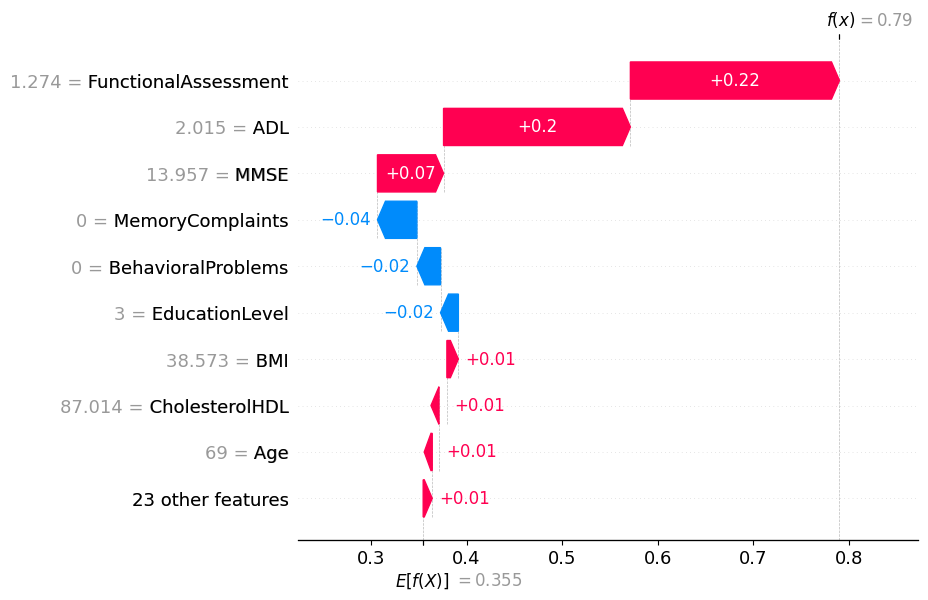

In [107]:
# Waterfall Plot for SHAP values of a specific patient
shap.plots.waterfall(shap_values_alz[patient_idx])

### Interpretation

The SHAP waterfall plot explains the prediction for an individual patient. The model's baseline prediction was 0.355, which increased to 0.79 for this patient. Functional Assessment (+0.22), ADL (+0.20), and MMSE (+0.07) were the largest contributors toward an Alzheimer's prediction. In contrast, the absence of Memory Complaints and Behavioral problems slightly decreased the prediction probability. Overall, the patient's functional and cognitive assessment scores were the primary factors driving the model toward an Alzheimer's prediction.

## 12. PCA - Patient Data Structure

In [ ]:
# Scaling the features before PCA
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

X_scaled.shape

(2149, 32)

In [ ]:
# Apply PCA
pca = PCA(n_components =2)
X_pca = pca.fit_transform(X_scaled)
print("PCA shape: ", X_pca.shape)

PCA shape:  (2149, 2)


In [110]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.03782383 0.03742685]
Total explained variance: 0.0752506847849651


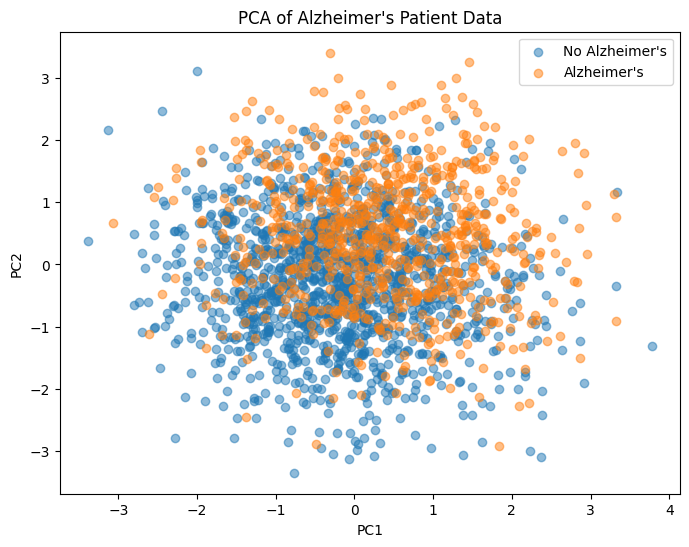

In [111]:
# Plot PC1 vs. PC2
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    alpha=0.5,
    label="No Alzheimer's"
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    alpha=0.5,
    label="Alzheimer's"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Alzheimer's Patient Data")
plt.legend()
plt.show()

In [112]:
# Examine PCA loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print("PC1:")
print(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("\nPC2:")
print(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

PC1:
Smoking                      0.379862
ADL                          0.350711
CardiovascularDisease        0.339457
FunctionalAssessment         0.309461
MemoryComplaints             0.270904
DifficultyCompletingTasks    0.256496
DiastolicBP                  0.231248
CholesterolHDL               0.215638
Diabetes                     0.214871
Ethnicity                    0.193867
Name: PC1, dtype: float64

PC2:
BMI                          0.334995
EducationLevel               0.308235
MMSE                         0.280629
FamilyHistoryAlzheimers      0.272030
CholesterolHDL               0.240236
FunctionalAssessment         0.240071
Gender                       0.226205
Disorientation               0.223980
DifficultyCompletingTasks    0.220843
Smoking                      0.196015
Name: PC2, dtype: float64


### Interpretation

PCA was used to reduce the 32-dimensional patient feature space into two principal components for visualization of the overall data structure. PC1 and PC2 explained approximately 3.78% and 3.74% of the total variance, respectively, accounting for 7.53% in total. The PC1–PC2 scatter plot showed substantial overlap between Alzheimer's and non-Alzheimer's patients, suggesting that the first two principal components alone do not clearly separate the two groups. Smoking, ADL, and CardiovascularDisease contributed strongly to PC1, while BMI, EducationLevel, and MMSE contributed strongly to PC2. These PCA loadings describe overall variation in the patient data rather than feature importance for Alzheimer's prediction.

## 13. Prediction Uncertainty with MAPIE

### 13.1 90% Conformal Prediction

In [120]:
from mapie.classification import SplitConformalClassifier

X_train_mapie, X_calib, y_train_mapie, y_calib = train_test_split(
    X_train, 
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


# Train the Random Forest Classifier on the training set for MAPIE
rf_mapie = RandomForestClassifier(n_estimators=100, random_state=42)
rf_mapie.fit(X_train_mapie, y_train_mapie)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Create a conformal classifier using MAPIE
mapie_clf = SplitConformalClassifier(
    estimator=rf_mapie,
    confidence_level=0.90, 
    # LAC was used as a straightforward conformal classification method to quantify uncertainty in the Random Forest predictions
    conformity_score="lac",
    prefit=True
)

mapie_clf.conformalize(X_calib, y_calib)

# Generate point predictions and prediction sets
y_pred_mapie, y_pred_set = mapie_clf.predict_set(X_test)

print("Prediction shape:", y_pred_mapie.shape)
print("Prediction set shape:", y_pred_set.shape)



Prediction shape: (430,)
Prediction set shape: (430, 2, 1)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Remove the confidence-level dimension
pred_set = y_pred_set[:, :, 0]

# Calculate prediction set sizes
set_sizes = pred_set.sum(axis=1)

print("Average prediction set size:", set_sizes.mean())
print("Number of singleton sets:", (set_sizes == 1).sum())
print("Number of ambiguous sets {0,1}:", (set_sizes == 2).sum())
print("Number of empty sets:", (set_sizes == 0).sum())


# Calculate empirical coverage
y_test_array = y_test.to_numpy()

covered = pred_set[
    np.arange(len(y_test_array)),
    y_test_array
]

coverage = covered.mean()

print("Empirical coverage:", coverage)

Average prediction set size: 0.9465116279069767
Number of singleton sets: 407
Number of ambiguous sets {0,1}: 0
Number of empty sets: 23
Empirical coverage: 0.9


### Interpretation

At the 90% confidence level, MAPIE achieved an empirical coverage of 90.0%, meaning that the true diagnosis was included in the prediction set for 90% of the test patients. Among the 430 patients, 407 received singleton prediction setss containing only one class, while 23 received empty prediction sets. No patients received ambiguous prediction sets containing both classes. The average prediction set size was 0.947. 

These results show that conformal prediction can provide uncertainty information beyond the Random Forest's point predictions by evaluating which classes can be included in a prediction set under the specified coverage level. 

### 13.2 Comparison across Confidence levels

In [131]:
# Compare multiple confidence levels
confidence_levels = [0.80, 0.90, 0.95]

mapie_compare = SplitConformalClassifier(
    estimator=rf_mapie,
    confidence_level=confidence_levels,
    conformity_score="lac",
    prefit=True
)

# Calibrate using the same calibration set
mapie_compare.conformalize(X_calib, y_calib)

# Generate prediction sets for each confidence level
y_pred_compare, y_pred_sets_compare = mapie_compare.predict_set(X_test)

print(y_pred_sets_compare.shape)

(430, 2, 3)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [132]:
# Summarize coverage and prediction set size
results = []

for i, confidence in enumerate(confidence_levels):

    pred_set = y_pred_sets_compare[:, :, i]

    # Calculate coverage
    covered = pred_set[
        np.arange(len(y_test_array)),
        y_test_array
    ]
    coverage = covered.mean()

    # Calculate prediction set sizes
    set_sizes = pred_set.sum(axis=1)

    avg_size = set_sizes.mean()
    empty = (set_sizes == 0).sum()
    singleton = (set_sizes == 1).sum()
    ambiguous = (set_sizes == 2).sum()

    results.append([
        confidence,
        coverage,
        avg_size,
        empty,
        singleton,
        ambiguous
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Confidence Level",
        "Empirical Coverage",
        "Average Set Size",
        "Empty Sets",
        "Singleton Sets",
        "Ambiguous Sets"
    ]
)

results_df

,Confidence Level,Empirical Coverage,Average Set Size,Empty Sets,Singleton Sets,Ambiguous Sets
0,0.80,0.800000,0.837209,70,360,0
1,0.90,0.900000,0.946512,23,407,0
2,0.95,0.955814,1.106977,0,384,46


### Interpretation

As the confidence level increased from 80% to 95%, empirical coverage increased from 80.0% to 95.6%, while the average prediction set size increased from 0.837 to 1.107. At the 80% confidence level, 70 patients received empty prediction sets, which decreaed to 23 at 90% and zero at 95%. At the 95% confidence level, however, 46 patients received ambiguous prediction sets containing both classes {0, 1}. 

This demonstrates the trade-off between coverage and informativeness in conformal prediction. Higher confidence levels increase the likelihood that the true diagnosis is included in the prediction set, but at the same time, this can result in larger and less specific prediction sets. In a healthcare context, these ambiguous predictions may help identify cases where the model cannot provide a sufficiently specific prediction and where additional evaluation could be considered. 

## 14. Key Findings

This project evaluated predictive performance, model interpretability, underlying data structure, and prediction uncertainty for Alzheimer's disease classifiaction. 

1. Tree-based models substantially outperformed the linear baseline. 
Logistic Regression achieved an accuracy of 81.6%, while Random Forest and XGBoost achieved 93.7% and 94.9%, respectively. XGBoost showed the highest predictive performance, while Random Forest provided comparable performance and was retained as the primary model for subsequent interpretation and uncertainty analysis. 

2. Functional and cognitive measures were important contributors to Random Forest predictions. 
SHAP analysis identified Functional Assessment, ADL, MMSE, and Memory Complaints among the most influential features. In particular, lower Functional Assessment, ADL, and MMSE values generally pushed predictions toward the Alzheimer's class, while higher values tended to push predictions toward the non-Alzheimer's class. 

3. Individual prediction could be explained at the patient level. 
SHAP waterfall plots showed how individual feature values contributed to a patient's prediction, allowing the model's overall prediction to be decomposed into feature-level contributions. 

4. The first two principal components captured only a small portion of the overall data variation.
PC1 and PC2 explained approximately 7.53% of the total variance. The substantial overlap between Alzheimer's and non-Alzheimer's patients in the PCA visualization suggests that the first two principal components alone do not fclearly separate the two diagnostic groups. 

5. Conformal prediction demonstrated a trade-off between coverage and prediction-set informativeness. 
As the confidence level increased from 80% to 95%, empirical coverage increased from 80.0% to 95.6%. At the 95% confidence level, there were no empty prediction sets, but 46 patients received ambigous {0,1} prediction sets, demonstrating that greater coverage can come at the cost of less specific predictions. 

## 15. Clinical Meaning

In healthcare applications, predictive performance alone may not be sufficient. It is also important to understand why a model makes a prediction and how much uncertainty is associated with that prediction.

In this project, Random Forest achieved strong predictive performance while SHAP provided insight into the features contributing to both overall and individual predictions. Functional and cognitive measures such as Functional Assessment, ADL, MMSE, and Memory Complaints were among the most influential features in the model.

MAPIE further complemented model interpretation by quantifying prediction uncertainty through conformal prediction sets. At higher confidence levels, the model achieved greater empirical coverage but sometimes produced prediction sets containing both diagnostic classes. In a healthcare setting, such ambiguous predictions could potentially be used to identify cases where additional evaluation or clinical review may be appropriate, rather than relying solely on a single model prediction.

Together, these results illustrate the potential value of combining predictive performance, interpretability, and uncertainty quantification when developing machine learning models for healthcare decision support.

## 16. Limitations & Future Work

Despite the strong predictive performance, this project has several important limitations.

First, the analysis was conducted using a **synthetic Alzheimer's patient dataset**. Therefore, the patterns captured by the models may not fully represent the complexity, variability, and measurement challenges present in real-world clinical data.

Second, the models were evaluated using a single train-test split without external validation. Although Random Forest and XGBoost achieved high predictive performance on the test set, their generalizability to other patient populations remains unknown.

Third, only the first two principal components were used for PCA visualization, explaining approximately 7.53% of the total variance. Therefore, the two-dimensional visualization represents only a limited portion of the overall structure of the dataset.

Finally, the conformal prediction results depend on the calibration data and should not be interpreted as guarantees of performance in real clinical settings.

Future work could evaluate these methods using real-world clinical datasets, perform cross-validation and systematic hyperparameter tuning, and validate the models on external patient populations. Additional approaches to model calibration and uncertainty quantification could also be explored.